In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.model_selection import train_test_split, KFold,cross_validate, StratifiedKFold,GridSearchCV,  RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from scipy.stats import randint
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

df = pd.read_csv('train.csv')
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [3]:
df = df.rename(columns={
    'datetime': '날짜',
    'season': '계절',
    'holiday': '주말',
    'workingday': '주중',
    'weather' : '날씨',
    'temp': '온도',
    'atemp': '체감온도',
    'humidity': '습도',
    'windspeed': '풍속',
    'casual': '사전등록X',
    'registered': '사전등록O',
    'count': '대여횟수'
})

df

,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,대여횟수
0,2011-01-01 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [4]:
계절별대여횟수 = df.groupby('계절')['대여횟수'].sum()
계절별대여횟수

계절
1    312498
2    588282
3    640662
4    544034
Name: 대여횟수, dtype: int64

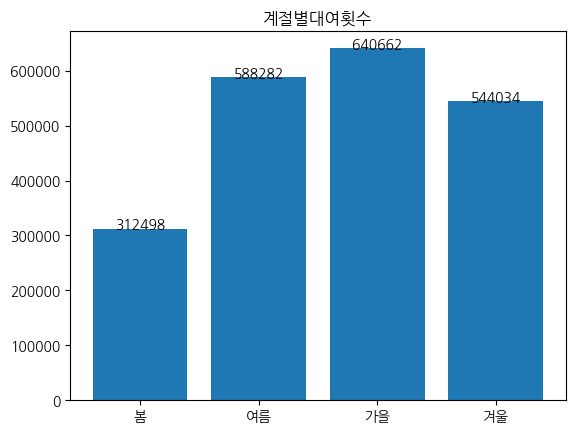

In [5]:
plt.bar(range(len(계절별대여횟수)), 계절별대여횟수)
plt.title('계절별대여횟수')
plt.xticks(
    range(len(계절별대여횟수)),
    ["봄", "여름", "가을", "겨울"]
)

for i, v in enumerate(계절별대여횟수):
    plt.text(i, v, f"{v}", ha='center')

plt.show()

In [6]:
날씨별대여횟수 = df.groupby('날씨')['대여횟수'].sum()
날씨별대여횟수

날씨
1    1476063
2     507160
3     102089
4        164
Name: 대여횟수, dtype: int64

In [144]:
연도별대여횟수 = df.groupby('년도')['대여횟수'].sum()
연도별대여횟수

년도
2011     781979
2012    1303497
Name: 대여횟수, dtype: int64

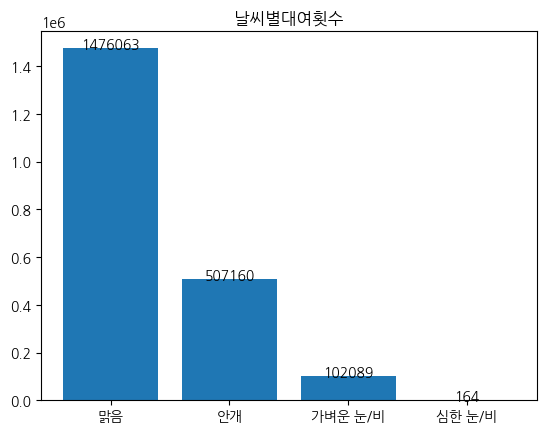

In [7]:
plt.bar(range(len(날씨별대여횟수)), 날씨별대여횟수)
plt.title('날씨별대여횟수')
plt.xticks(
    range(len(날씨별대여횟수)),
    ["맑음", "안개", "가벼운 눈/비", "심한 눈/비"]
)

for i, v in enumerate(날씨별대여횟수):
    plt.text(i, v, f"{v}", ha='center')

plt.show()

In [8]:
df['온도구간'] = (df['온도'] // 10).astype(int) * 10
df

,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,대여횟수,온도구간
0,2011-01-01 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0
1,2011-01-01 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,0
2,2011-01-01 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,0
3,2011-01-01 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,0
4,2011-01-01 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,10
10882,2012-12-19 20:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,10
10883,2012-12-19 21:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,10
10884,2012-12-19 22:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,10


,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,대여횟수,온도구간,시간,년도,월,일
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0,0,2011,1,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,0,1,2011,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,0,2,2011,1,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,0,3,2011,1,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,0,4,2011,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,10,19,2012,12,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,10,20,2012,12,19
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,10,21,2012,12,19
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,10,22,2012,12,19


In [10]:
시간별대여횟수 = df.groupby('시간')['대여횟수'].sum()
시간별대여횟수

시간
0      25088
1      15372
2      10259
3       5091
4       2832
5       8935
6      34698
7      96968
8     165060
9     100910
10     79667
11     95857
12    116968
13    117551
14    111010
15    115960
16    144266
17    213757
18    196472
19    143767
20    104204
21     79057
22     60911
23     40816
Name: 대여횟수, dtype: int64

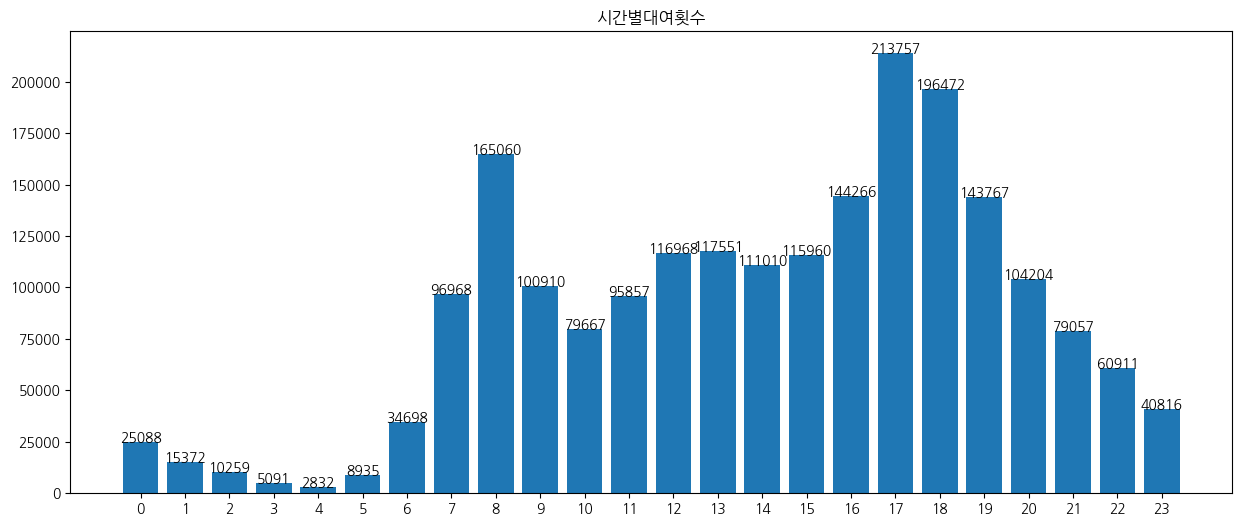

In [11]:
plt.figure(figsize=(15,6))
plt.bar(시간별대여횟수.index, 시간별대여횟수)
plt.xticks(시간별대여횟수.index)
plt.title('시간별대여횟수')
for i, v in enumerate(시간별대여횟수):
    plt.text(i, v + 5, f"{v}", ha='center')

plt.show()

In [12]:
df['회원이용률'] = df['사전등록O'] / (df['대여횟수'] + 1)
df

,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,대여횟수,온도구간,시간,년도,월,일,회원이용률
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0,0,2011,1,1,0.764706
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,0,1,2011,1,1,0.780488
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,0,2,2011,1,1,0.818182
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,0,3,2011,1,1,0.714286
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,0,4,2011,1,1,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,10,19,2012,12,19,0.976261
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,10,20,2012,12,19,0.954545
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,10,21,2012,12,19,0.970414
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,10,22,2012,12,19,0.900000


In [215]:
요일별대여횟수 = df.groupby('요일')['대여횟수'].sum()
요일별대여횟수

요일
0    295296
1    291985
2    292226
3    306401
4    302504
5    311518
6    285546
Name: 대여횟수, dtype: int64

In [244]:
df['날짜'] = pd.to_datetime(df['날짜'])
df['시간'] = df['날짜'].dt.hour
df['년도'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day
df['러시아워'] = df['시간'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)
df['온도습도'] = df['온도'] * df['습도']
df['최악의날씨'] = df['날씨'].apply(lambda x: 1 if x >= 3 else 0)
df['좋은날씨'] = df['날씨'].apply(lambda x: 1 if x == 1 else 0)
def time_group(hour):
    if 7 <= hour <= 9:
        return "출근"
    elif 17 <= hour <= 19:
        return "퇴근"
    elif 12 <= hour <= 13:
        return "점심"
    elif 0 <= hour <= 5:
        return "심야"
    else:
        return "일반"
df['날씨점수'] = df['좋은날씨'] - df['최악의날씨']
df['시간_세분화'] = df['시간'].apply(time_group)
df['출퇴근_시간'] = df['시간'] * df['주중']
df['요일'] = pd.to_datetime(df['날짜']).dt.dayofweek
df['시간/날씨'] = df['시간'] * df['날씨']
def temp_group(x):
    if x < 5:
        return 0   # 추움
    elif x < 15:
        return 1   # 선선
    elif x < 25:
        return 2   # 적당
    else:
        return 3   # 더움

df['체감온도_구간'] = df['체감온도'].apply(temp_group)
df['불쾌지수'] = 0.81 * df['체감온도'] + 0.01 * df['습도'] * (0.99 * df['체감온도'] - 14.3) + 46.3
df

,날짜,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,...,날씨점수,출퇴근_시간,요일,출퇴근_날씨,시간/날씨,체감온도_구간,불쾌지수,계절_2,계절_3,계절_4
0,2011-01-01 00:00:00,0,0,1,9.84,14.395,81,0.0000,3,13,...,1,0,5,0,0,1,57.920300,False,False,False
1,2011-01-01 01:00:00,0,0,1,9.02,13.635,80,0.0000,8,32,...,1,0,5,0,1,1,56.703270,False,False,False
2,2011-01-01 02:00:00,0,0,1,9.02,13.635,80,0.0000,5,27,...,1,0,5,0,2,1,56.703270,False,False,False
3,2011-01-01 03:00:00,0,0,1,9.84,14.395,75,0.0000,3,10,...,1,0,5,0,3,1,57.923237,False,False,False
4,2011-01-01 04:00:00,0,0,1,9.84,14.395,75,0.0000,0,1,...,1,0,5,0,4,1,57.923237,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,0,1,1,15.58,19.695,50,26.0027,7,329,...,1,19,2,19,19,2,64.851975,False,False,True
10882,2012-12-19 20:00:00,0,1,1,14.76,17.425,57,15.0013,10,231,...,1,20,2,20,20,2,62.096177,False,False,True
10883,2012-12-19 21:00:00,0,1,1,13.94,15.910,61,15.0013,4,164,...,1,21,2,21,21,2,60.072149,False,False,True
10884,2012-12-19 22:00:00,0,1,1,13.94,17.425,61,6.0032,12,117,...,1,22,2,22,22,2,62.214208,False,False,True


In [256]:
df

,날짜,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,...,계절_2,계절_3,계절_4,온도구간_1,온도구간_2,온도구간_3,시간_세분화_일반,시간_세분화_점심,시간_세분화_출근,시간_세분화_퇴근
0,2011-01-01 00:00:00,0,0,1,9.84,14.395,81,0.0000,3,13,...,False,False,False,False,False,False,False,False,False,False
1,2011-01-01 01:00:00,0,0,1,9.02,13.635,80,0.0000,8,32,...,False,False,False,False,False,False,False,False,False,False
2,2011-01-01 02:00:00,0,0,1,9.02,13.635,80,0.0000,5,27,...,False,False,False,False,False,False,False,False,False,False
3,2011-01-01 03:00:00,0,0,1,9.84,14.395,75,0.0000,3,10,...,False,False,False,False,False,False,False,False,False,False
4,2011-01-01 04:00:00,0,0,1,9.84,14.395,75,0.0000,0,1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,0,1,1,15.58,19.695,50,26.0027,7,329,...,False,False,True,True,False,False,False,False,False,True
10882,2012-12-19 20:00:00,0,1,1,14.76,17.425,57,15.0013,10,231,...,False,False,True,True,False,False,True,False,False,False
10883,2012-12-19 21:00:00,0,1,1,13.94,15.910,61,15.0013,4,164,...,False,False,True,True,False,False,True,False,False,False
10884,2012-12-19 22:00:00,0,1,1,13.94,17.425,61,6.0032,12,117,...,False,False,True,True,False,False,True,False,False,False


In [216]:
불쾌지수별대여횟수 = df.groupby('불쾌지수')['대여횟수'].sum()
불쾌지수별대여횟수

불쾌지수
38.625027      24
42.197328      21
42.200126      27
42.309416       2
42.600785      15
             ... 
95.081131    1063
95.617510    1854
95.948177     849
96.176670     899
97.026111     421
Name: 대여횟수, Length: 1179, dtype: int64

In [258]:
if '시간_세분화' in df.columns:
    df = pd.get_dummies(df, columns=['시간_세분화'], drop_first=True)

if '온도구간' in df.columns:
    df = pd.get_dummies(df, columns=['온도구간'], drop_first=True)

if '계절' in df.columns:
    df = pd.get_dummies(df, columns=['계절'], drop_first=True)

if '날씨' in df.columns:
    df = pd.get_dummies(df, columns=['날씨'], drop_first=True)

In [259]:

X = df.drop(columns=['대여횟수', '사전등록O','사전등록X','날짜'])
y = df['대여횟수']

In [260]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [261]:
LGBMmodel = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    random_state=42,
    force_col_wise=True,
    verbosity=-1
)
# 1. 파라미터 설정
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 2. 교차검증
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. 그리드서치
grid_search = GridSearchCV(
    estimator=XGBmodel,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, np.log1p(y_train))   # 여기 변경

# 4. 결과 확인
print("최적 파라미터:", grid_search.best_params_)
print("최고 CV RMSE:", -grid_search.best_score_)

# 5. 최적 모델 꺼내기
bestXGBmodel = grid_search.best_estimator_
bestXGBmodel.fit(X_train, np.log1p(y_train))  # 여기 변경

# 예측
y_pred_log = bestXGBmodel.predict(X_test)     # 로그 상태 예측
y_pred = np.expm1(y_pred_log)                 # 원래값 복원
y_pred = np.clip(y_pred, 0, None)             # 음수 제거
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}
최고 CV RMSE: 0.25951954847216196
RMSE: 35.079332523759625


      feature  importance
6          시간    0.295221
33  시간_세분화_퇴근    0.230453
18     출퇴근_시간    0.098702
7          년도    0.067384
11       러시아워    0.035070
35       날씨_3    0.030199
8           월    0.029379
1          주중    0.022517
2          온도    0.021400
13      최악의날씨    0.019467
30  시간_세분화_일반    0.019317
10      회원이용률    0.016805
3        체감온도    0.016576
19         요일    0.015989
21      시간/날씨    0.014324
23       불쾌지수    0.013041
4          습도    0.008032
20     출퇴근_날씨    0.007901
34       날씨_2    0.005437
32  시간_세분화_출근    0.004519
14       좋은날씨    0.004451
0          주말    0.003556
25       계절_3    0.003417
12       온도습도    0.002842
31  시간_세분화_점심    0.002633
9           일    0.002612
5          풍속    0.002413
28     온도구간_2    0.002316
27     온도구간_1    0.002057
24       계절_2    0.001967
17       날씨점수    0.000000
15        온도2    0.000000
16        습도2    0.000000
26       계절_4    0.000000
22    체감온도_구간    0.000000
29     온도구간_3    0.000000
36       날씨_4    0.000000


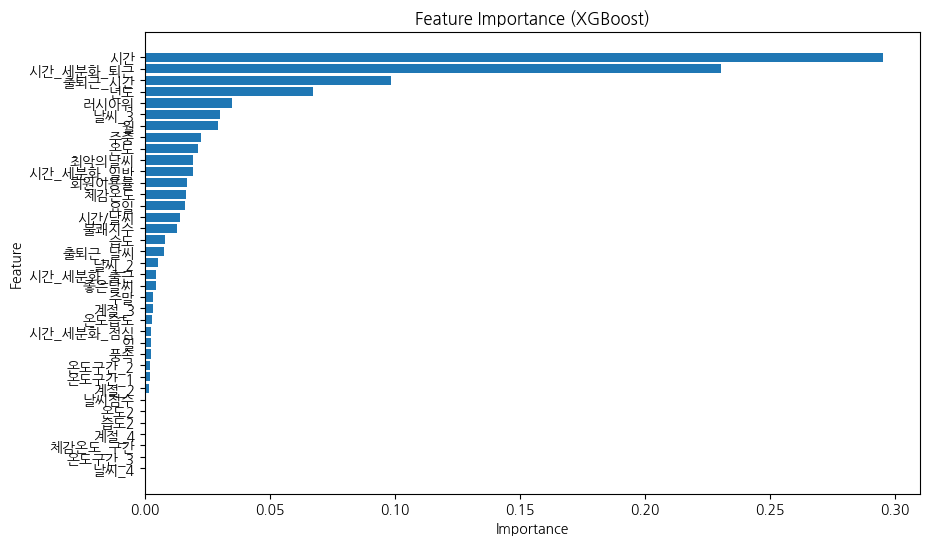

In [262]:
import pandas as pd
import matplotlib.pyplot as plt

# 중요도 가져오기
importance = bestXGBmodel.feature_importances_

# 컬럼 이름과 합치기
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
})

# 정렬
feature_importance_df = feature_importance_df.sort_values(
    by='importance', ascending=False
)

print(feature_importance_df)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.gca().invert_yaxis()

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

MAE : 22.066822052001953
MSE : 1230.5595703125
RMSE: 35.079332523759625
RMSLE: 0.26220594978492884


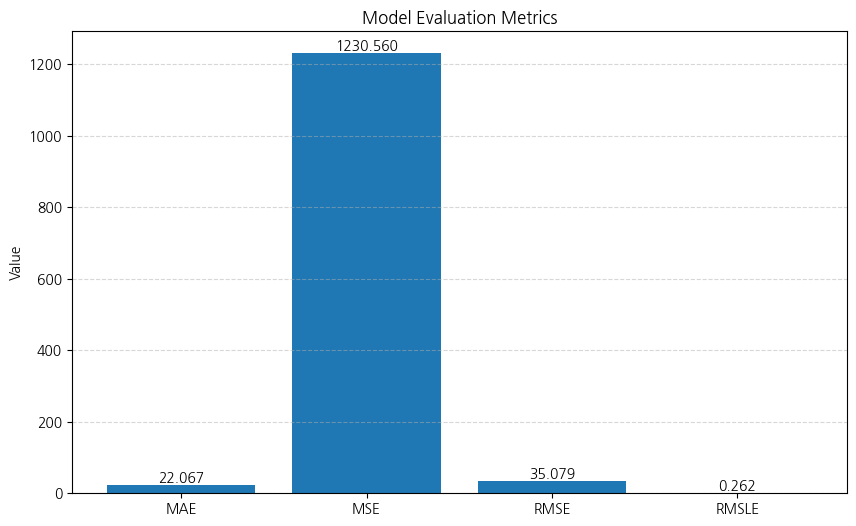

In [263]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 예측 (이미 있으니까 이어서)
# -----------------------------
y_pred_log = bestXGBmodel.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_pred = np.clip(y_pred, 0, None)

# -----------------------------
# 지표 계산
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# RMSLE (로그 오차)
rmsle = np.sqrt(mean_squared_error(
    np.log1p(y_test),
    np.log1p(y_pred)
))

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("RMSLE:", rmsle)

import matplotlib.pyplot as plt

metrics = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "RMSLE": rmsle
}

names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(names, values)

plt.title("Model Evaluation Metrics")
plt.ylabel("Value")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 값 표시
for i, v in enumerate(values):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

===== 테스트셋 기준 모델별 RMSE =====
XGBoost : 35.0793
HistGB : 39.5095
LightGBM : 39.7858
RandomForest : 40.5907
Ridge : 108.5468
Lasso : 148.5771


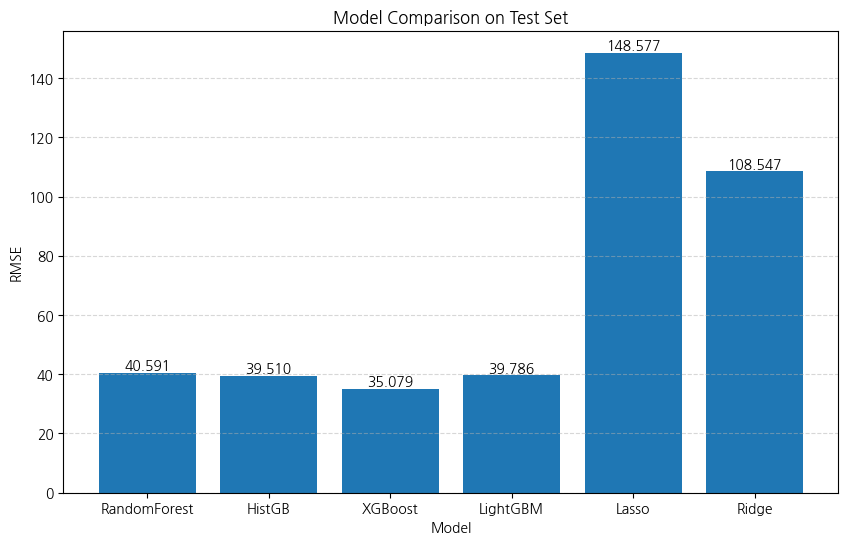

In [264]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import mean_squared_error

models = {
    "RandomForest": RFmodel,
    "HistGB": HGMmodel,
    "XGBoost": bestXGBmodel,
    "LightGBM": LGBMmodel,
    "Lasso": LSmodel,
    "Ridge": Rmodel
}

results = {}

for name, model in models.items():
    temp_model = clone(model)
    
    # 로그 학습
    temp_model.fit(X_train, np.log1p(y_train))
    
    # 예측
    y_pred_log = temp_model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[name] = rmse

print("===== 테스트셋 기준 모델별 RMSE =====")
for name, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name} : {rmse:.4f}")

# 그래프
model_names = list(results.keys())
rmse_values = list(results.values())

plt.figure(figsize=(10, 6))
plt.bar(model_names, rmse_values)
plt.title("Model Comparison on Test Set")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(rmse_values):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

In [265]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -----------------------------------
# 1. 모델 모음
# -----------------------------------
models = {
    "RandomForest": RFmodel,
    "HistGB": HGMmodel,
    "XGBoost": bestXGBmodel,
    "LightGBM": LGBMmodel,
    "Lasso": LSmodel,
    "Ridge": Rmodel
}

# -----------------------------------
# 2. 결과 저장용 리스트
# -----------------------------------
results_list = []

# -----------------------------------
# 3. 각 모델별 학습 / 예측 / 평가
# -----------------------------------
for name, model in models.items():
    temp_model = clone(model)
    
    # 로그 변환해서 학습
    temp_model.fit(X_train, np.log1p(y_train))
    
    # 예측
    y_pred_log = temp_model.predict(X_test)
    
    # 원래 값으로 복원
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)
    
    # 평가 지표 계산
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred)))
    r2 = r2_score(y_test, y_pred)
    
    # 결과 저장
    results_list.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "RMSLE": rmsle,
        "R2": r2
    })

# -----------------------------------
# 4. DataFrame 생성
# -----------------------------------
results_df = pd.DataFrame(results_list)

# RMSE 기준 정렬 (낮을수록 좋음)
results_df = results_df.sort_values(by="RMSE", ascending=True)

# 보기 좋게 반올림
results_df = results_df.round(4)

# 인덱스 정리
results_df = results_df.reset_index(drop=True)

results_df

,Model,MAE,MSE,RMSE,RMSLE,R2
0,XGBoost,22.0668,1230.5596,35.0793,0.2622,0.9627
1,HistGB,24.7734,1561.0014,39.5095,0.2798,0.9527
2,LightGBM,24.7826,1582.9129,39.7858,0.2795,0.9520
3,RandomForest,25.1812,1647.6088,40.5907,0.2963,0.9501
4,Ridge,69.6049,11782.4009,108.5468,0.6858,0.6430
5,Lasso,98.9205,22075.1604,148.5771,0.9623,0.3312


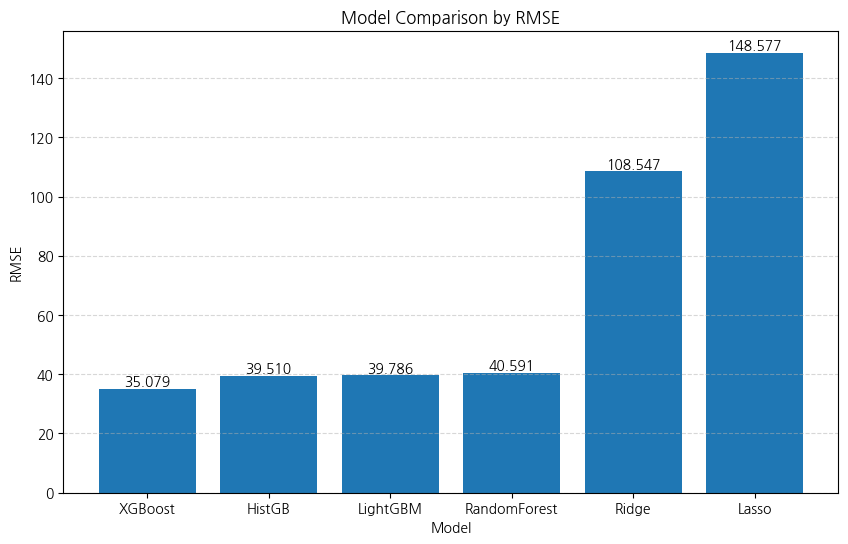

In [266]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(results_df["RMSE"]):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

plt.show()